In [4]:
from zipfile import ZipFile

dataset = 'Files\dogs-vs-cats.zip'

with ZipFile(dataset, 'r') as zip:
    zip.extractall()
    print('Dataset is extracted!')

Dataset is extracted!


In [17]:
from zipfile import ZipFile

dataset = r'Files\train.zip'

with ZipFile(dataset, 'r') as zip:
    zip.extractall()
    print('Dataset is extracted!')

Dataset is extracted!


In [ ]:
import os
path, dirs, files = next(os.walk('train_catsvsdogs'))
file_count = len(files)
print(file_count)

25000


In [ ]:
file_names = os.listdir('train_catsvsdogs')
print(file_names)

['cat.0.jpg', 'cat.1.jpg', 'cat.10.jpg', 'cat.100.jpg', 'cat.1000.jpg', 'cat.10000.jpg', 'cat.10001.jpg', 'cat.10002.jpg', 'cat.10003.jpg', 'cat.10004.jpg', 'cat.10005.jpg', 'cat.10006.jpg', 'cat.10007.jpg', 'cat.10008.jpg', 'cat.10009.jpg', 'cat.1001.jpg', 'cat.10010.jpg', 'cat.10011.jpg', 'cat.10012.jpg', 'cat.10013.jpg', 'cat.10014.jpg', 'cat.10015.jpg', 'cat.10016.jpg', 'cat.10017.jpg', 'cat.10018.jpg', 'cat.10019.jpg', 'cat.1002.jpg', 'cat.10020.jpg', 'cat.10021.jpg', 'cat.10022.jpg', 'cat.10023.jpg', 'cat.10024.jpg', 'cat.10025.jpg', 'cat.10026.jpg', 'cat.10027.jpg', 'cat.10028.jpg', 'cat.10029.jpg', 'cat.1003.jpg', 'cat.10030.jpg', 'cat.10031.jpg', 'cat.10032.jpg', 'cat.10033.jpg', 'cat.10034.jpg', 'cat.10035.jpg', 'cat.10036.jpg', 'cat.10037.jpg', 'cat.10038.jpg', 'cat.10039.jpg', 'cat.1004.jpg', 'cat.10040.jpg', 'cat.10041.jpg', 'cat.10042.jpg', 'cat.10043.jpg', 'cat.10044.jpg', 'cat.10045.jpg', 'cat.10046.jpg', 'cat.10047.jpg', 'cat.10048.jpg', 'cat.10049.jpg', 'cat.1005.jpg'

In [3]:
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
import os

In [ ]:
img = mpimg.imread('train_catsvsdogs/dog.7181.jpg')

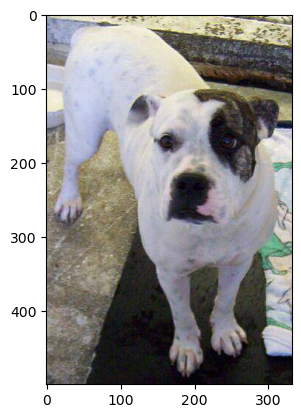

In [29]:
plt.imshow(img)
plt.show()

In [ ]:
# Resizing all the images
file_names = os.listdir('train_catsvsdogs')

dog_count = 0
cat_count = 0

for img_file in file_names:
    name = img_file[0:3]
    if name == 'dog':
        dog_count += 1
    else:
        cat_count += 1

print(f'Number of dog images: {dog_count}')
print(f'Number of cat images: {cat_count}')

Number of dog images: 12500
Number of cat images: 12500


In [33]:
original_folder = 'train_catsvsdogs/'
resized_folder = 'image_resized/'

for img_name in file_names:
    img_path = original_folder+img_name

    img = Image.open(img_path)
    img = img.resize((224, 224))
    img = img.convert('RGB')

    new_img_path = resized_folder+img_name
    img.save(new_img_path)


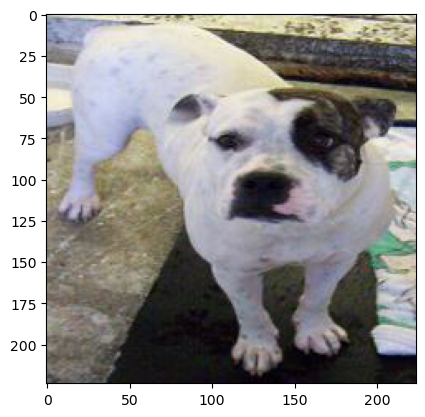

In [35]:
img = mpimg.imread('image_resized/dog.7181.jpg')
plt.imshow(img)
plt.show()

Dog --> 0

Cat --> 1

In [4]:
labels = []
file_names = os.listdir('image_resized')

for img_name in file_names:
    label = img_name[0:3]
    if label == 'dog':
        labels.append(0)
    else:
        labels.append(1)

In [5]:
print(len(labels))
print(labels[0], labels[-1])

25000
1 0


In [6]:
import random
random.seed(3)
selected_images = random.sample(range(0, 25001), 2000)
labels = [labels[i] for i in selected_images]

file_names = [file_names[i] for i in selected_images]

In [7]:
values, counts = np.unique(labels, return_counts=True)
print(values, counts)

[0 1] [ 997 1003]


In [8]:
import cv2
import glob

In [9]:
image_dir = 'image_resized/'
image_extension = ['png', 'jpg']

files = [image_dir + file for file in file_names]

#[files.extend(glob.glob(image_dir + '*.' + e)) for e in image_extension]

dog_cat_images = np.asarray([cv2.imread(file) for file in files])

In [10]:
dog_cat_images.shape

(2000, 224, 224, 3)

In [11]:
X = dog_cat_images
y = np.asarray(labels)

Train Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=3)

In [13]:
print(X.shape, X_train.shape, X_test.shape)

(2000, 224, 224, 3) (1600, 224, 224, 3) (400, 224, 224, 3)


In [14]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [15]:
print(X_train_scaled, X_test_scaled)

[[[[0.03137255 0.14117647 0.2627451 ]
   [0.03137255 0.14117647 0.2627451 ]
   [0.03529412 0.1372549  0.25490196]
   ...
   [0.07058824 0.11372549 0.16862745]
   [0.06666667 0.10980392 0.16470588]
   [0.0627451  0.10588235 0.16078431]]

  [[0.02745098 0.1372549  0.25882353]
   [0.02745098 0.1372549  0.25882353]
   [0.03529412 0.1372549  0.25490196]
   ...
   [0.06666667 0.11764706 0.17254902]
   [0.07843137 0.12156863 0.17647059]
   [0.0745098  0.1254902  0.18039216]]

  [[0.02352941 0.13333333 0.25490196]
   [0.02352941 0.13333333 0.25490196]
   [0.03529412 0.1372549  0.25490196]
   ...
   [0.04313725 0.10588235 0.15686275]
   [0.05882353 0.10980392 0.16470588]
   [0.05882353 0.12156863 0.17254902]]

  ...

  [[0.41568627 0.40784314 0.43137255]
   [0.41568627 0.40784314 0.43137255]
   [0.41960784 0.41176471 0.43529412]
   ...
   [0.50980392 0.48235294 0.49411765]
   [0.50980392 0.48235294 0.49411765]
   [0.51372549 0.48627451 0.49803922]]

  [[0.42352941 0.41176471 0.44705882]
   [0.4

In [16]:
import tensorflow as tf
import tensorflow_hub as hub

In [17]:
mobilenet_model = 'https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4'

pretrained_model = hub.KerasLayer(mobilenet_model, input_shape=(224,224,3), trainable=False)
print(type(pretrained_model))

<class 'tensorflow_hub.keras_layer.KerasLayer'>


In [18]:
model = tf.keras.Sequential([
    pretrained_model,
    tf.keras.layers.Dense(2, activation='softmax')
])

model.summary()

ValueError: Only instances of `keras.Layer` can be added to a Sequential model. Received: <tensorflow_hub.keras_layer.KerasLayer object at 0x000001C4952F2660> (of type <class 'tensorflow_hub.keras_layer.KerasLayer'>)